In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats
import sys 
sys.path.append('/astrodata/romain/')
from sax_utils import rebin_lc_genau

/tmp/ipykernel_2032443/2272698085.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


1


Text(0, 0.5, 'Counts')

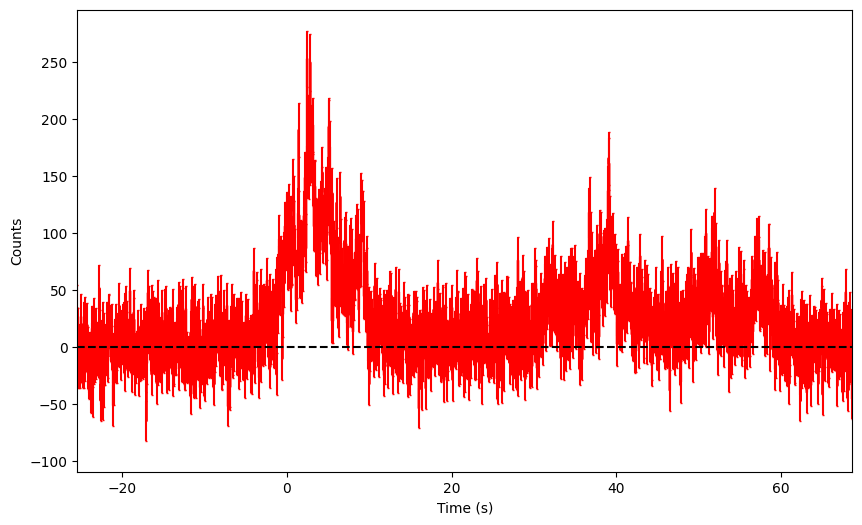

In [62]:
instr = 'batse'
path_lc = f'lc_sim/{instr}'
#for i in range(5):
i = np.random.randint(0,20)
data = np.loadtxt(f'{path_lc}/lc_sim_{i}.txt')
mepsa_res = pd.read_csv(f'{path_lc}/mepsa_res_lc_sim_{i}.txt',sep='\s+',names=['#Peak', 'RebinFactor' ,'BinPhase', 'PeakTime', 'BinTime', 'PeakRate', 'PeakRateError', 'SNR', 'Criteria', 'Adjacents'],comment="#")
mepsa_res = mepsa_res[mepsa_res['SNR'].values>5]
rebf = np.min(mepsa_res['RebinFactor'])
print(rebf)
x_reb,y_reb,z_reb = rebin_lc_genau(data[:,0], data[:,1], data[:,2],rebf=rebf,ren=True)
trig_time = mepsa_res['PeakTime'].values[0]
plt.figure(figsize=(10,6))
plt.step(x_reb-trig_time,y_reb, where='post',color='r')
plt.errorbar(x_reb+0.064*rebf/2-trig_time,y_reb, yerr=z_reb,color='r',fmt='',ls='',capsize=1)
dur = mepsa_res['PeakTime'].values[-1]-mepsa_res['PeakTime'].values[0]
plt.xlim(mepsa_res['PeakTime'].values[0]-10*mepsa_res['BinTime'].values[0]-trig_time-0.4*dur, mepsa_res['PeakTime'].values[0]+1.2*dur-trig_time)
plt.xlabel('Time (s)')
plt.axhline(0, color='k', linestyle='--')
#plt.xlim(0,1.5)
plt.ylabel('Counts')
#plt.legend()

2 <class 'numpy.int64'>
2 <class 'numpy.int64'>
1 <class 'numpy.int64'>
1 <class 'numpy.int64'>
1 <class 'numpy.int64'>
2 <class 'numpy.int64'>
2 <class 'numpy.int64'>
4 <class 'numpy.int64'>
1 <class 'numpy.int64'>


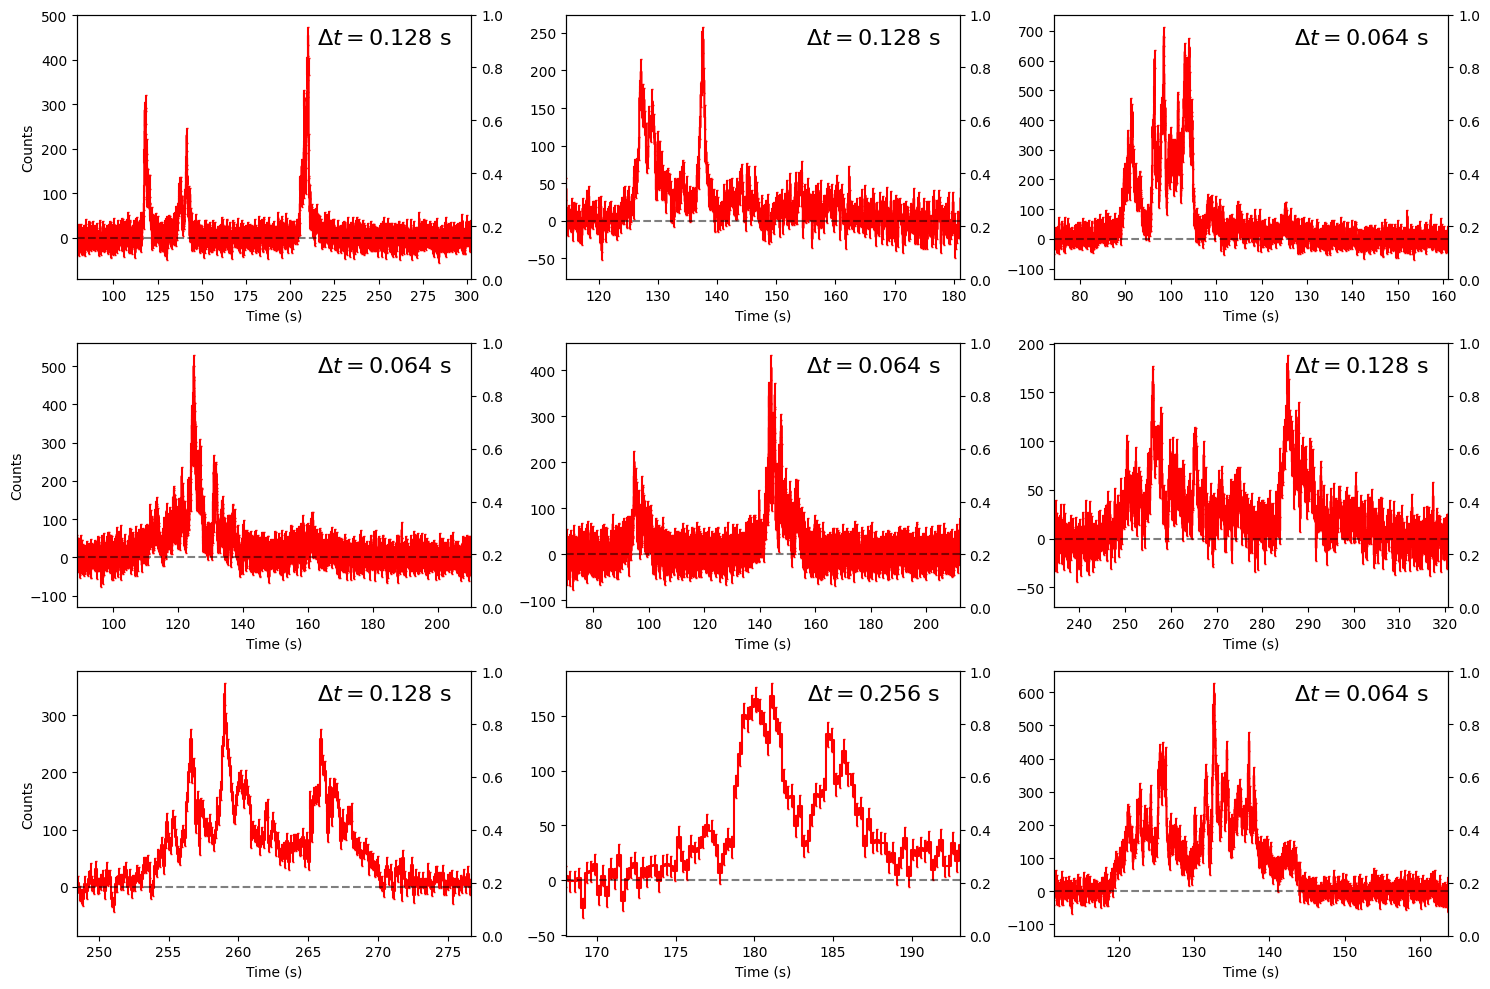

In [81]:
# make a figure with 4*3 subplots, each with a different random lc
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
for i in range(3):
    axs[i,0].set_ylabel('Counts')
    for j in range(3):
        axs[i,j].set_xlabel('Time (s)')
        i_rand = np.random.randint(0,200)
        data = np.loadtxt(f'{path_lc}/lc_sim_{i_rand}.txt')
        mepsa_res = pd.read_csv(f'{path_lc}/mepsa_res_lc_sim_{i_rand}.txt',sep='\s+',names=['#Peak', 'RebinFactor' ,'BinPhase', 'PeakTime', 'BinTime', 'PeakRate', 'PeakRateError', 'SNR', 'Criteria', 'Adjacents'],comment="#")
        mepsa_res = mepsa_res[mepsa_res['SNR'].values>7]

        while len(mepsa_res)==0:
            i_rand = np.random.randint(0,50)
            data = np.loadtxt(f'{path_lc}/lc_sim_{i_rand}.txt')
            mepsa_res = pd.read_csv(f'{path_lc}/mepsa_res_lc_sim_{i_rand}.txt',sep='\s+',names=['#Peak', 'RebinFactor' ,'BinPhase', 'PeakTime', 'BinTime', 'PeakRate', 'PeakRateError', 'SNR', 'Criteria', 'Adjacents'],comment="#")
            mepsa_res = mepsa_res[mepsa_res['SNR'].values>7]
            #if np.min(mepsa_res['RebinFactor'])==np.nan or type(np.min(mepsa_res['RebinFactor']))==float:
        #    rebf = 1
        #else:
    #    print(np.min(mepsa_res['RebinFactor']))
        rebf = np.min(mepsa_res['RebinFactor'])
        print(rebf,type(rebf))
        x_reb,y_reb,z_reb = rebin_lc_genau(data[:,0], data[:,1], data[:,2],rebf=rebf,ren=True)
        trig_time = mepsa_res['PeakTime'].values[0]
        trig_time = 0
        axs[i,j].step(x_reb-trig_time,y_reb, where='post',color='r')
        axs[i,j].errorbar(x_reb+0.064*rebf/2-trig_time,y_reb, yerr=z_reb,color='r',fmt='',ls='',capsize=1)
        axs[i,j].text(0.95,0.95,r'$\Delta t=$'+"%1.3f"%(rebf*0.064)+' s',transform=axs[i,j].transAxes, ha='right', va='top',size=16)
        dur = mepsa_res['PeakTime'].values[-1]-mepsa_res['PeakTime'].values[0]
        axs[i,j].set_xlim(mepsa_res['PeakTime'].values[0]-10*mepsa_res['BinTime'].values[0]-trig_time-0.4*dur, mepsa_res['PeakTime'].values[0]+2*dur-trig_time)   
        axs[i,j].axhline(0, color='k', linestyle='--',alpha=0.5)
        trig_time = mepsa_res['PeakTime'].values[0]
        ax2 = axs[i,j].twinx()
        #ax2.step(x_reb-trig_time,y_reb, where='post',color='r')
plt.tight_layout()
plt.savefig(f'{instr}_results/lc_sim_examples_bpl_{instr}.pdf')

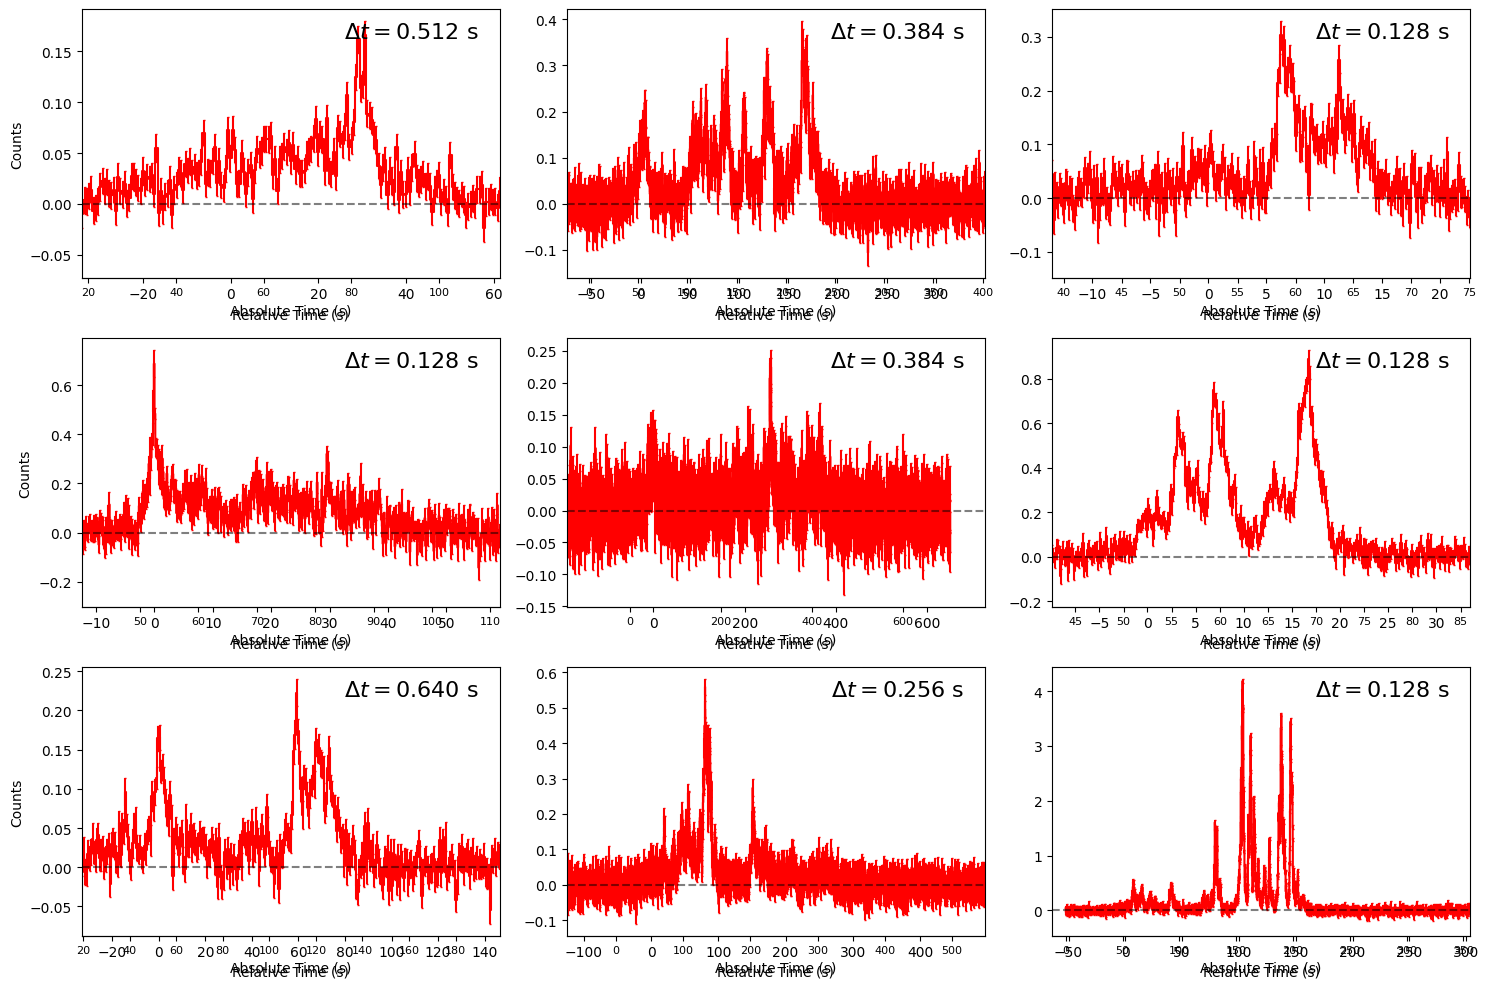

In [88]:
# make a figure with 3*3 subplots, each with a different random lc
fig, axs = plt.subplots(3, 3, figsize=(15, 10))

for i in range(3):
    axs[i,0].set_ylabel('Counts')
    for j in range(3):
        axs[i,j].set_xlabel('Relative Time (s)') # Label for bottom axis
        
        i_rand = np.random.randint(0,500)
        data = np.loadtxt(f'{path_lc}/lc_sim_{i_rand}.txt')
        mepsa_res = pd.read_csv(f'{path_lc}/mepsa_res_lc_sim_{i_rand}.txt',sep='\s+',names=['#Peak', 'RebinFactor' ,'BinPhase', 'PeakTime', 'BinTime', 'PeakRate', 'PeakRateError', 'SNR', 'Criteria', 'Adjacents'],comment="#")
        mepsa_res = mepsa_res[mepsa_res['SNR'].values>6]
        
        rebf = 2*np.min(mepsa_res['RebinFactor'])
        x_reb, y_reb, z_reb = rebin_lc_genau(data[:,0], data[:,1], data[:,2], rebf=rebf, ren=True)
        
        # Define your non-zero trigger time for shifting
        trig_time = mepsa_res['PeakTime'].values[0] 
        
        # Plotting the shifted data on the primary axis
        axs[i,j].step(x_reb - trig_time, y_reb, where='post', color='r')
        axs[i,j].errorbar(x_reb + 0.064*rebf/2 - trig_time, y_reb, yerr=z_reb, color='r', fmt='', ls='', capsize=1)
        
        axs[i,j].text(0.95, 0.95, r'$\Delta t=$'+"%1.3f"%(rebf*0.064)+' s', transform=axs[i,j].transAxes, ha='right', va='top', size=16)
        
        dur = mepsa_res['PeakTime'].values[-1] - mepsa_res['PeakTime'].values[0]
        axs[i,j].set_xlim(mepsa_res['PeakTime'].values[0] - 10*mepsa_res['BinTime'].values[0] - trig_time - 0.4*dur, mepsa_res['PeakTime'].values[0] + 2*dur - trig_time)   
        axs[i,j].axhline(0, color='k', linestyle='--', alpha=0.5)
        
        # --- THE FIX: Add the secondary shifted X-axis at the top ---
        # Define functions to convert back and forth between relative and absolute time
        forward = lambda x: x + trig_time
        inverse = lambda x: x - trig_time
        
        # Create the top X-axis linked to the bottom X-axis scale
        ax_top = axs[i,j].secondary_xaxis('bottom', functions=(forward, inverse))
        ax_top.set_xlabel('Absolute Time (s)', fontsize=10)
        ax_top.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

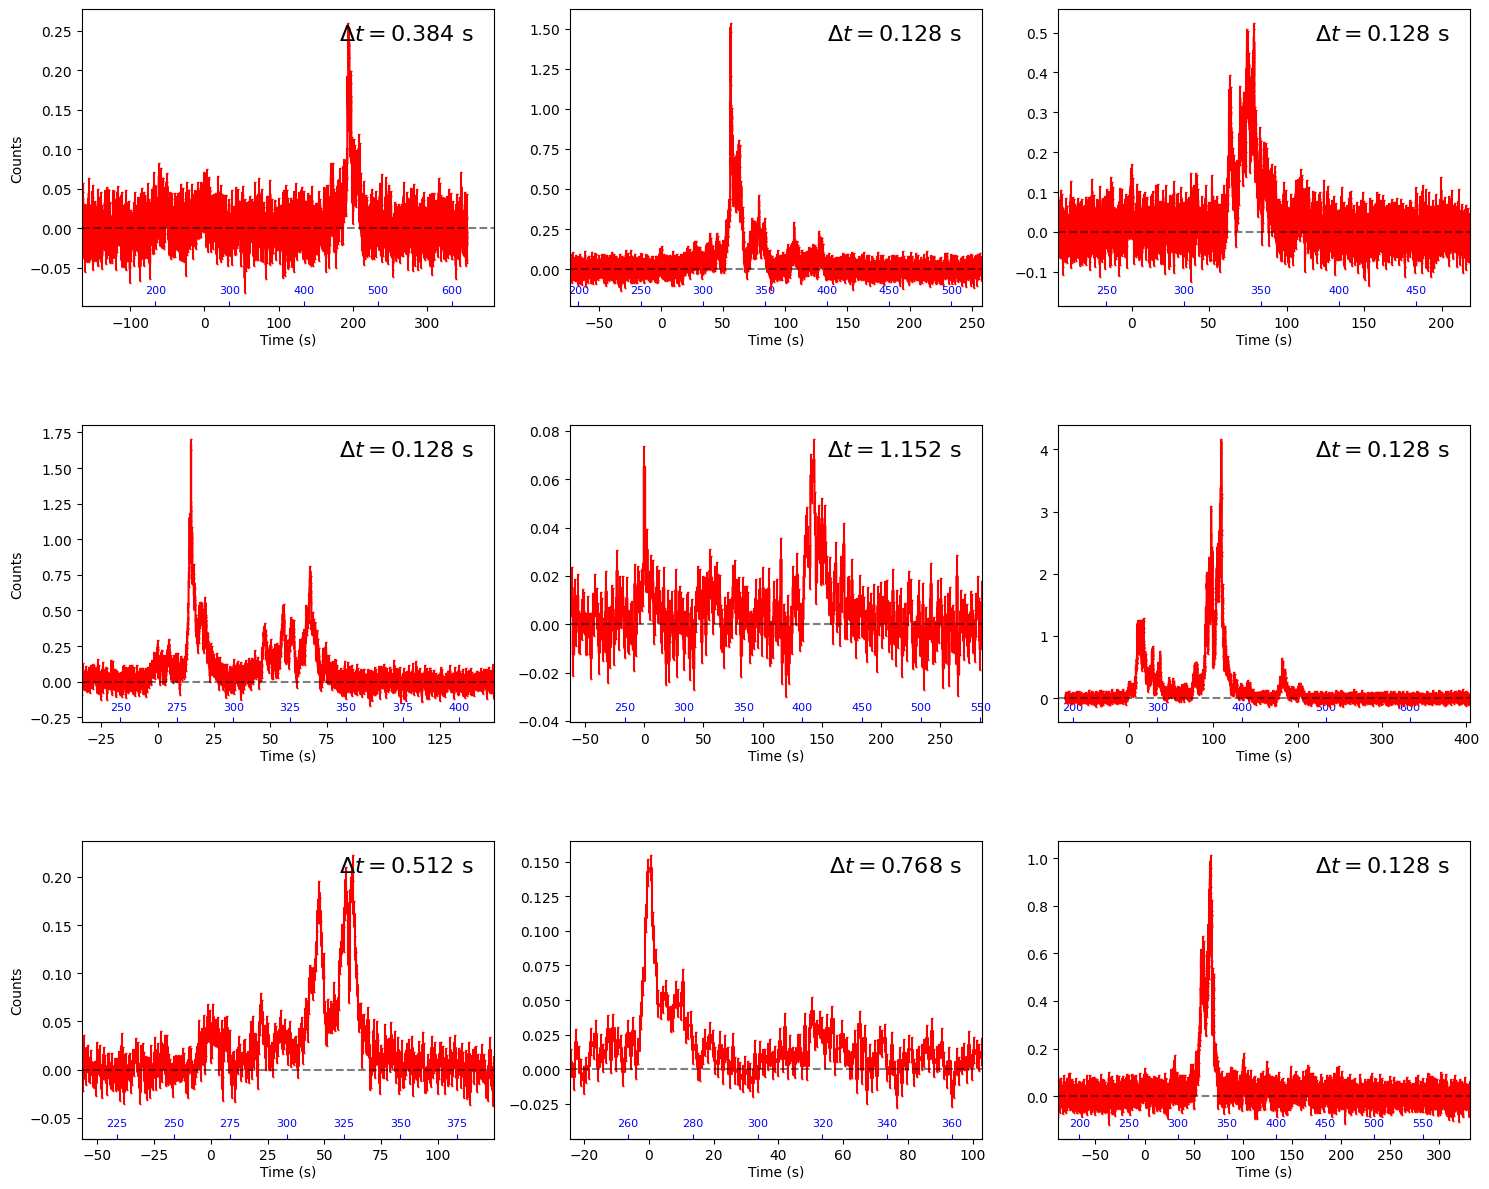

In [99]:
# make a figure with 3*3 subplots, each with a different random lc
fig, axs = plt.subplots(3, 3, figsize=(15, 12)) 

for i in range(3):
    axs[i,0].set_ylabel('Counts')
    for j in range(3):
        # 1. Primary Bottom Axis (Relative Time)
        axs[i,j].set_xlabel('Time (s)', labelpad=2) 
        
        i_rand = np.random.randint(0,500)
        data = np.loadtxt(f'{path_lc}/lc_sim_{i_rand}.txt')
        mepsa_res = pd.read_csv(f'{path_lc}/mepsa_res_lc_sim_{i_rand}.txt',sep='\s+',names=['#Peak', 'RebinFactor' ,'BinPhase', 'PeakTime', 'BinTime', 'PeakRate', 'PeakRateError', 'SNR', 'Criteria', 'Adjacents'],comment="#")
        mepsa_res = mepsa_res[mepsa_res['SNR'].values>6]
        
        rebf = 2*np.min(mepsa_res['RebinFactor'])
        x_reb, y_reb, z_reb = rebin_lc_genau(data[:,0], data[:,1], data[:,2], rebf=rebf, ren=True)
        
        trig_time = mepsa_res['PeakTime'].values[0] 
        
        axs[i,j].step(x_reb - trig_time, y_reb, where='post', color='r')
        axs[i,j].errorbar(x_reb + 0.064*rebf/2 - trig_time, y_reb, yerr=z_reb, color='r', fmt='', ls='', capsize=1)
        
        axs[i,j].text(0.95, 0.95, r'$\Delta t=$'+"%1.3f"%(rebf*0.064)+' s', transform=axs[i,j].transAxes, ha='right', va='top', size=16)
        
        dur = mepsa_res['PeakTime'].values[-1] - mepsa_res['PeakTime'].values[0]
        axs[i,j].set_xlim(mepsa_res['PeakTime'].values[0] - 10*mepsa_res['BinTime'].values[0] - trig_time - 0.4*dur, mepsa_res['PeakTime'].values[0] + 2*dur - trig_time)   
        axs[i,j].axhline(0, color='k', linestyle='--', alpha=0.5)
        
        # 2. Secondary Stacked Axis (Absolute Time)
        forward = lambda x: x + trig_time
        inverse = lambda x: x - trig_time
        
        ax_secondary = axs[i,j].secondary_xaxis('bottom', functions=(forward, inverse))
        ax_secondary.spines['bottom'].set_position(('outward', 0)) 
        #ax_secondary.set_xlabel('Absolute Time (s)', fontsize=10)
        ax_secondary.tick_params(axis='x', labelsize=8,color='blue')
        
        # --- THE FIX: Force secondary ticks to point UP ---
        ax_secondary.tick_params(axis='x', direction='in', pad=-15,colors='blue') 
        # Optional: Adjust pad if the numbers overlap the tick marks

plt.tight_layout()
fig.subplots_adjust(hspace=0.4) 
plt.show()